In [57]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
from sklearn.model_selection import cross_val_score


In [58]:
# 데이터 불러오기
df = pd.read_csv('C:/Users/user/Desktop/프로젝트데이터/만족도데이터전처리/노인만족도조사2022_원핫인코딩v0.1.csv', encoding='utf-8')
# df = pd.read_csv('C:/Users/user/Desktop/프로젝트 데이터/만족도데이터전처리/노인만족도조사2022_정규화.csv', encoding='cp949')

# 타깃 값 (예: 삶의 만족도 점수)를 y로 가정 (사용자에 맞게 선택 필요)
# 예: df['satisfaction_score'] 가 타깃이면 아래처럼 수정
# X는 나머지 모든 컬럼
# y = df['satisfaction_score']  # 예시: 만족함 확률 예측
# X = df.drop(columns=['satisfaction_score'])
# 변수 선택 (Lasso)
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)
selected_columns = X.columns[(lasso.coef_ != 0)]
X = X[selected_columns]  # 중요 변수만 선택

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_columns)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
import numpy as np

# 하이퍼파라미터 탐색 설정
param_dist = {
    'n_estimators': [300, 500, 800, 1000],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# 모델 튜닝 실행
rfr = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rfr,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# 결과 출력
print("최고 성능 R²:", random_search.best_score_)
print("최적 하이퍼파라미터:", random_search.best_params_)

# 최적 모델로 테스트 예측
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
# 평가
print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

cv_r2_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='r2')

# 교차검증 RMSE 점수 (neg_root_mean_squared_error는 음수이므로 -붙여야 양수로)
cv_rmse_scores = -cross_val_score(best_model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')

# 결과 출력
print("🔁 교차검증 R² 목록:", np.round(cv_r2_scores, 4).tolist())
print("📊 교차검증 평균 R²:", round(cv_r2_scores.mean(), 4))
print("🔁 교차검증 RMSE 목록:", np.round(cv_rmse_scores, 4).tolist())
print("📉 교차검증 평균 RMSE:", round(cv_rmse_scores.mean(), 4))


import pandas as pd
from sklearn.preprocessing import StandardScaler

# 중요도 기반 피처 제거
importances = best_model.feature_importances_
importance_series = pd.Series(importances, index=X.columns)

# 하위 20% 중요도 피처 제거
threshold = importance_series.quantile(0.2)
low_importance_features = importance_series[importance_series <= threshold].index.tolist()

# 피처 제거 후 재구성
X_reduced = X.drop(columns=low_importance_features)

# 스케일링 + 데이터 분할
X_scaled_reduced = StandardScaler().fit_transform(X_reduced)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_scaled_reduced, y, test_size=0.2, random_state=42)

# 최적 파라미터로 RandomForest 재학습
rfr_reduced = RandomForestRegressor(**random_search.best_params_, random_state=42)
rfr_reduced.fit(X_train_r, y_train_r)
y_pred_r = rfr_reduced.predict(X_test_r)

# 성능 출력
print("\n✅ 중요도 낮은 피처 제거 후 성능:")
print("R²:", r2_score(y_test_r, y_pred_r))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_r)))

최고 성능 R²: 0.3738522430764253
최적 하이퍼파라미터: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Test R²: 0.3842932913522846
Test RMSE: 0.6620349932385017
🔁 교차검증 R² 목록: [0.4233, 0.3667, 0.2752, 0.3356, 0.3529]
📊 교차검증 평균 R²: 0.3507
🔁 교차검증 RMSE 목록: [0.7135, 0.7035, 0.6952, 0.6396, 0.6688]
📉 교차검증 평균 RMSE: 0.6841

✅ 중요도 낮은 피처 제거 후 성능:
R²: 0.37511767405512175
RMSE: 0.6669497643516179


In [61]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,           # L1 정규화
    reg_lambda=1.0,          # L2 정규화
    random_state=42
)

X_scaled_reduced = StandardScaler().fit_transform(X_reduced)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_scaled_reduced, y, test_size=0.2, random_state=42)


# xgb_model.fit(X_train, y_train)
# y_pred_xgb = xgb_model.predict(X_test)
xgb_model.fit(X_train_r, y_train_r)
y_pred_xgb_r = xgb_model.predict(X_test_r)

print("XGBoost (피처제거 후) Test R²:", r2_score(y_test_r, y_pred_xgb_r))
print("XGBoost (피처제거 후) RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_xgb_r)))


# print("\n✅ XGBoost 성능:")
# print("XGBoost Test R²:", r2_score(y_test, y_pred_xgb))
# print("XGBoost Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

# # 교차검증
# cv_r2_xgb = cross_val_score(xgb_model, X_scaled, y, cv=5, scoring='r2')
# cv_rmse_xgb = -cross_val_score(xgb_model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')

# print("XGBoost 교차검증 평균 R²:", round(cv_r2_xgb.mean(), 4))
# print("XGBoost 교차검증 평균 RMSE:", round(cv_rmse_xgb.mean(), 4))

XGBoost (피처제거 후) Test R²: 0.38645613193511963
XGBoost (피처제거 후) RMSE: 0.6608711750489111


In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.ensemble import RandomForestRegressor
# import numpy as np
# # 4. 모델 학습
# # model = LinearRegression()

# # model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)

# # model = RandomForestRegressor(  #과적합은 줄었지만 성능이 너무 낮게 됨
# #     n_estimators=300,   #트리개수 클수록 안정적 (300, 500, 300)
# #     max_depth=8,        #트리의 최대깊이 (8, 12, 8)
# #     min_samples_split=10,    #내부노드분할 최소샘플수 (5, 3, 10)
# #     min_samples_leaf=5,     #리프노드 최소 샘플수 (3, 2, 5)
# #     max_features='log2'        #각 노드에서 고려할 특성수 (sqrt, )
# #     # random_state='42'
# # )

# model = RandomForestRegressor(
#     n_estimators=800,
#     max_depth=15,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     max_features='sqrt',
#     random_state=42
# )

# model.fit(X_train, y_train) #아래로 교체
# # 예측
# y_pred_train = model.predict(X_train)
# y_pred_test = model.predict(X_test)

# # R² 계산
# r2_train = r2_score(y_train, y_pred_train)
# r2_test = r2_score(y_test, y_pred_test)


# # RMSE 계산 수동 방식 (squared 옵션 없이)
# rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
# rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))


# # 결과 출력
# print(f"📈 R² (Train): {r2_train:.4f}")
# print(f"📈 R² (Test) : {r2_test:.4f}")
# print(f"📉 RMSE (Train): {rmse_train:.4f}")
# print(f"📉 RMSE (Test) : {rmse_test:.4f}")

# from sklearn.model_selection import cross_val_score
# # 교차검증 R²와 RMSE 점수 각각
# cv_r2_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
# cv_rmse_scores = -cross_val_score(model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')

# # 출력
# print("교차검증 선형회귀 R² 목록:", np.round(cv_r2_scores, 4).tolist())
# print("교차검증 선형회귀 평균 R²:", round(cv_r2_scores.mean(), 4))

# print("교차검증 선형회귀 RMSE 목록:", np.round(cv_rmse_scores, 4).tolist())
# print("교차검증 선형회귀 평균 RMSE:", round(cv_rmse_scores.mean(), 4))


📈 R² (Train): 0.8412
📈 R² (Test) : 0.3795
📉 RMSE (Train): 0.3422
📉 RMSE (Test) : 0.6646
교차검증 선형회귀 R² 목록: [0.4206, 0.3663, 0.2793, 0.3288, 0.3498]
교차검증 선형회귀 평균 R²: 0.349
교차검증 선형회귀 RMSE 목록: [0.7152, 0.7037, 0.6932, 0.6429, 0.6704]
교차검증 선형회귀 평균 RMSE: 0.6851


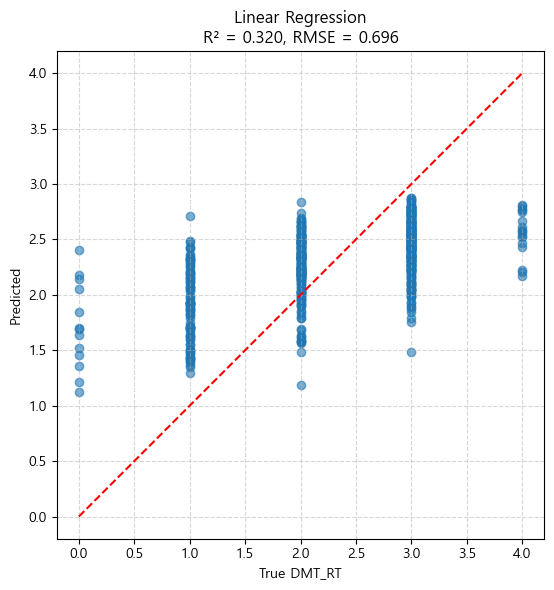

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지



# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6,  )
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True DMT_RT")
plt.ylabel("Predicted")
plt.title(f"Linear Regression\nR² = {r2_test:.3f}, RMSE = {rmse_test:.3f}")
plt.axis('square')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_8992\2924513004.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


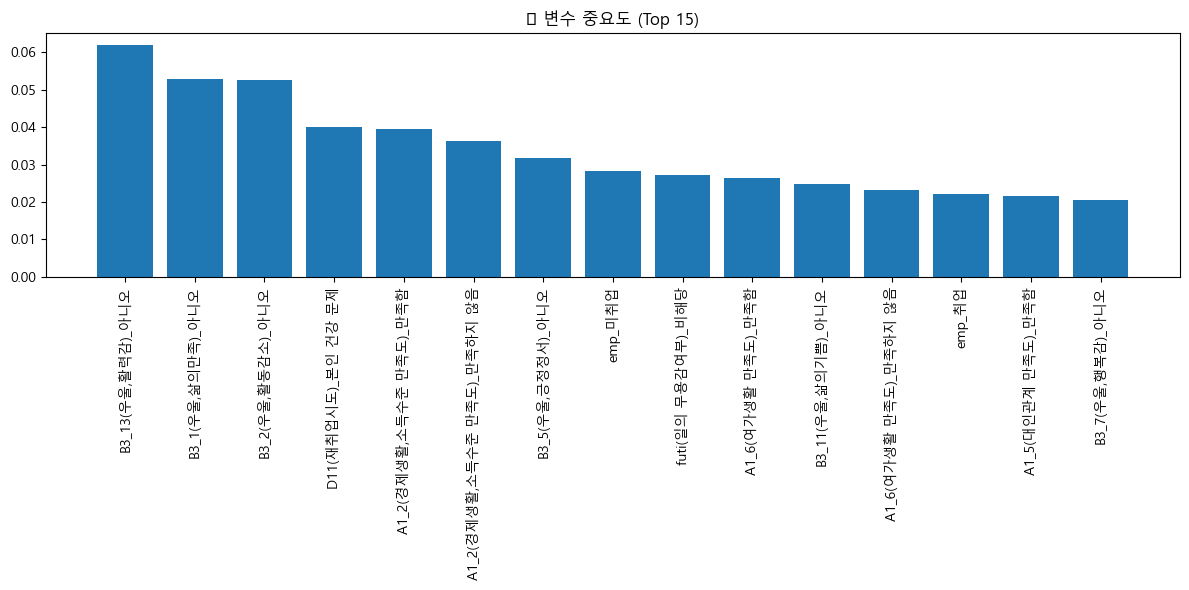

In [52]:

# 변수 중요도 추출
# coef_model = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
import matplotlib.pyplot as plt

# 변수 중요도 시각화 (RandomForest 기준)
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns[indices]

# 시각화 (Top 15 변수)
plt.figure(figsize=(12, 6))
plt.title("🔍 변수 중요도 (Top 15)")
plt.bar(range(15), importances[indices[:15]])
plt.xticks(range(15), features[:15], rotation=90)
plt.tight_layout()

# plt.figure(figsize=(12, 6)) 2
# plt.title("🎯 변수 중요도 (top15)") 2
# plt.bar(range(len(features[:15])), importances[indices[:15]]) 2
# plt.xticks(range(len(features[:15])), features[:15], rotation=90) 2
# plt.tight_layout() 2

# coef_model.head(15).plot(kind='barh', color='darkcyan') 1
# plt.title("선형 회귀 - 변수 중요도 (절댓값 기준 Top 15)") 1
# plt.xlabel("회귀 계수 크기") 1
# plt.gca().invert_yaxis() 1
# plt.grid(True, axis='x', linestyle='--', alpha=0.5) 1
# plt.tight_layout() 1
plt.show()